# Do concept citation chains survive in new fields?

**Artifact `art_yjFB8Spw2w6M` (iteration 2, experiment 2): citation gate and viability labels.** This is a runnable demo of the original `method.py`.

The research question is whether an emerging scientific concept that *enters* a new host subfield $d$ (outside its origin subfield $o$) is then **reproduced locally**, with host papers citing earlier host papers on the same concept. The alternative is that the concept is only **imported** each year from outside. The experiment answers this with citation lineages *inside* each concept's own paper set (OpenAlex works, iteration-1 corpus):

1. **Gate A (STEP 2):** for every main-arm host edge-year $(c,d,t)$ with $|K_d|\ge 10$ children, it computes the *within-host, non-canonical traced share*. This is the share of host children (years $t-4..t$) that cite at least one earlier non-canonical c-paper in the same host subfield. Gate A passes iff more than 50% of edges have a share $\ge 0.40$. On the full corpus it **FAILS**: 17.3% of 724 edges pass, mean 0.20. The lenient any-parent share from iteration 1 is 0.48 on the same edges.
2. **Viability layer (STEP 3, descriptive only):** per edge it computes the local reproduction ratio
   $\rho = \sum a / \sum b$ (weighted citations from children $K_d$ to cohort parents $P_d$, divided by the cohort-parent count) and an import ratio $m$. It then gets paper-cluster bootstrap CIs and p-values against a benchmark $\rho_0(d,t)$ from **stationary reference concepts** (pooling hierarchy L1–L5), applies Benjamini–Hochberg within each $(c,t)$ family, and assigns the states **SOURCE / SINK / FADING / UNDETERMINED**.

Every edge-year function only sees papers dated $\le t$ (the `W1View` leakage guard).

**What this demo runs:** the original code for the `gate_a` and `viability` stages of `method.py`, on a curated subset of **26 main + 10 reference concepts** (`mini_demo_data.json`). The data was already passed through the original `io_load.prepare()` (dedup, within-concept citation pairs, lenient flags). The other stages (synthetic validation, power analysis, P1, audit, figures) need the full 206-concept corpus and about 25 CPU-minutes, so they are not part of this demo. Their headline numbers are quoted in the last cell.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports

This cell holds the original import block of `method.py` and the `src/` modules it uses. `matplotlib` is added for the final visualisation. The original sets single-threaded BLAS before importing numpy, and that is kept.

In [2]:
from __future__ import annotations

import json
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")
import hashlib
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt  # notebook addition (visualisation)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data (GitHub URL with local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-2/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{data['n_main']} main + {data['n_reference']} reference concepts, "
      f"{sum(len(e['papers']['work_id']) for e in data['examples'])} papers, "
      f"{sum(len(e['cites']) for e in data['examples'])} within-concept citations")

Curated subset of the iteration-1 OpenAlex concept corpus (art_94GEMUsgAmgK) after the original io_load preparation: per concept, the dedup'ed c-papers (work_id, year, primary-topic subfield, field, n_refs, 2026 cited_by_count, lenient_excl_F flag) and the within-concept citation pairs (child_idx, parent_idx). 'full_run_host_edges' holds the full-run viability_layer.csv rows for the same concept (for comparison only).
26 main + 10 reference concepts, 32786 papers, 91531 within-concept citations


## Configuration

The tunable parameters are:
- `B`: bootstrap replicates per edge. The original (`config.yaml`) uses **1000**. The same `B` sets the number of REF_BOOT benchmark resamples.
- `N_MAIN_CONCEPTS` / `N_REF_CONCEPTS`: how many of the demo's main and reference concepts to run. The demo holds 26 and 10; the original corpus has 184 main and 22 reference concepts.
- `SEED`: the original seed from `config.yaml`.

The edge rules (|W1| ≥ 10, `n_min`, BH q = 0.10, the SINK m-threshold of 0.5, the benchmark hierarchy) are **pre-registered constants**. They stay in the code cells below, exactly as in the original.

In [5]:
B = 1000               # bootstrap replicates (original: 1000)
N_MAIN_CONCEPTS = 26   # main-arm concepts to run (demo max 26; original corpus: 184)
N_REF_CONCEPTS = 10    # reference-arm concepts for the rho0 benchmark (demo max 10; original: 22)
SEED = 20261001        # original seed (config.yaml)

RESULTS = Path("results")          # original: <workspace>/results
CACHE = RESULTS / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

## Rebuild the prepared corpus from the demo data (replaces `io_load.prepare()`)

In the original, `io_load.prepare()` reads the iteration-1 dataset: concept pool, `concept_work.parquet`, the works parquet shards and subfield-year totals. It returns a dict `G` with
- `concepts`: concept metadata (arm, fold, first year `F`, origin subfield, …)
- `tax`: the subfield → field map
- `per[cid] = {"papers": DataFrame, "cites": int array (child_idx, parent_idx)}`: dedup'ed c-papers sorted by year, and every within-concept citation.

Here the same structure is rebuilt from `data`, so the rest of the code runs unchanged. The graft-fallback keyword sets (`kw`) and the no-dedup link table for the lenient loader check are not included; see the Gate A section.

In [6]:
def build_G(data: dict, n_main: int, n_ref: int) -> dict:
    ex_main = [e for e in data["examples"] if e["concept"]["arm"] == "main"][:n_main]
    ex_ref = [e for e in data["examples"] if e["concept"]["arm"] == "reference"][:n_ref]
    concepts = pd.DataFrame([e["concept"] for e in ex_main + ex_ref])
    per = {}
    for e in ex_main + ex_ref:
        p = e["papers"]
        papers = pd.DataFrame({
            "work_id": np.asarray(p["work_id"], np.int64), "year": np.asarray(p["year"], np.int32),
            "sub": np.asarray(p["sub"], np.int32), "field": np.asarray(p["field"], np.int32),
            "n_refs": np.asarray(p["n_refs"], np.int32), "cbc": np.asarray(p["cbc"], np.int64),
            "lenient_excl_F": np.asarray(p["lenient_excl_F"], bool)})
        arr = np.asarray(e["cites"], np.int32).reshape(-1, 2)
        per[e["concept"]["concept_id"]] = {"papers": papers, "cites": arr}
    tax = {"sub_field": {int(k): int(v) for k, v in data["taxonomy_sub_field"].items()}}
    return {"concepts": concepts, "tax": tax, "per": per}


def load_totals() -> dict[tuple[int, int], int]:
    # original: io_load.load_totals() reads context/subfield_year_totals.json ("all_types" variant)
    return {(int(k.split("|")[0]), int(k.split("|")[1])): int(v) for k, v in data["subfield_year_totals"].items()}


G = build_G(data, N_MAIN_CONCEPTS, N_REF_CONCEPTS)
print(G["concepts"].groupby("arm").size().to_dict())
G["concepts"][["concept_id", "phrase", "arm", "fold", "F", "origin_sub", "route"]].head(8)

{'main': 26, 'reference': 10}


,concept_id,phrase,arm,fold,F,origin_sub,route
0,c_2cfdd88c29c0,body area sensor network,main,heldout_concept,2007.0,2204.0,A_openalex_native
1,c_e8febadc6f35,community question answering,main,screen,2008.0,1710.0,B_s2_index
2,c_8cebebdabedf,d2d network,main,heldout_concept,2013.0,2208.0,B_s2_index
3,c_007a7950eb4d,dantzig selector,main,screen,2007.0,2613.0,B_s2_index
4,c_7afec8c4aadb,deep recurrent neural network,main,screen,2013.0,1702.0,B_s2_index
5,c_9cceb3c510be,einstein podolsky rosen steering,main,screen,2011.0,3107.0,A_openalex_native
6,c_da11b8df9771,fidelity susceptibility,main,heldout_concept,2008.0,3107.0,B_s2_index
7,c_ef7889a4d23e,graphene growth,main,screen,2008.0,2505.0,B_s2_index


## Shared helpers (`src/common.py`)

`h32` gives a stable per-task seed, so bootstrap draws do not depend on the order in which tasks are scheduled. `f_band` buckets the concept's first year `F`.

In [7]:
def h32(s: str) -> int:
    """Stable 32-bit hash of a string (for per-task seeds, independent of scheduling)."""
    return int(hashlib.sha1(s.encode()).hexdigest()[:8], 16)


def f_band(F: int) -> str:
    return "2005-07" if F <= 2007 else ("2008-11" if F <= 2011 else "2012-16")

## Leakage guard (`src/leakage.py`)

`w1_view(cdata, t)` restricts a concept's papers **and** citations to years $\le t$ and re-indexes them. Every edge-year function asserts that it received such a view with `t_max == t`. The original codebase checks this guard with a mutation test: injected post-$t$ papers leave the outputs byte-identical.

In [8]:
@dataclass(frozen=True)
class W1View:
    papers: pd.DataFrame      # c-papers with year <= t (row order = original order, prefix of a year-sorted table)
    cites: np.ndarray         # (child_idx, parent_idx) with BOTH endpoints inside the view
    t_max: int
    n_total: int              # rows in the underlying table (only used for mapping, never for statistics)


def w1_view(cdata: dict, t: int) -> W1View:
    p = cdata["papers"]
    keep = (p["year"].to_numpy() <= t)
    idx = np.flatnonzero(keep)
    remap = -np.ones(len(p), np.int64)
    remap[idx] = np.arange(len(idx))
    view = p.iloc[idx].reset_index(drop=True).copy()
    view.attrs["t_max"] = t
    c = cdata["cites"]
    if len(c):
        ok = keep[c[:, 0]] & keep[c[:, 1]]
        cc = np.stack([remap[c[ok, 0]], remap[c[ok, 1]]], axis=1).astype(np.int64)
    else:
        cc = np.zeros((0, 2), np.int64)
    v = W1View(papers=view, cites=cc, t_max=t, n_total=len(p))
    check_view(v, t)
    return v


def check_view(v: W1View, t: int) -> None:
    assert isinstance(v, W1View), "edge-year functions accept only a W1View"
    assert v.t_max == t, f"view t_max {v.t_max} != t {t}"
    assert v.papers.attrs.get("t_max") == t
    if len(v.papers):
        assert int(v.papers["year"].max()) <= t, "view contains papers after t"

## Lineage: parentage, edge vectors, ρ and m (`src/lineage.py`)

- **Canonical papers**: the concept's first-year (F) papers plus the top 5 by 2026 citation count. They are excluded as parents, so a child that cites only the famous seed papers is *not* traced.
- **Parentage**: every citation from a child to an earlier-or-same-year non-canonical c-paper gets weight $\propto e^{-\Delta y/\tau}$ with $\tau=2$. Weights are normalised per child.
- **Edge vectors** for host $d$ at year $t$: cohort parents $P_d$ are non-canonical d-papers from years $t-5..t-3$, and children $K_d$ are d-papers from years $t-4..t$. Per unit this gives $a$ (weight on $P_d$ parents), $b$ (being a cohort parent), `imp` (weight on parents outside $d$) and `tr` (the child is traced).
  $\rho=\sum a/\sum b$ is the local reproduction ratio; $m=\sum \text{imp}/\sum \text{tr}$ is the import share.
- The **Gate-A statistic** `within_host_share` is the share of $K_d$ citing at least one non-canonical parent in $d$ dated $\ge t-5$. `lenient_share` is iteration 1's any-parent flag on the same children.
- **Momentum** is the OLS slope of the log per-10k share of the concept in $d$ over the last 6 years (the W1 baseline).

In [9]:
TAU = 2.0  # parent-age decay of w_kp


def canonical_main(papers: pd.DataFrame, F: int | None, top: int = 5) -> set[int]:
    """F-year c-papers plus top-5 by 2026 cited_by_count (ties -> lower work_id). The only declared post-t input."""
    s = papers.sort_values(["cbc", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(papers.work_id[papers.year == F].tolist())
    return canon


def canonical_w1(view: W1View, F: int | None, t: int, top: int = 5) -> set[int]:
    """CANON_W1 sensitivity: F-year papers + top-5 by in-concept citations received from c-papers with year <= t."""
    check_view(view, t)
    p = view.papers
    cnt = np.bincount(view.cites[:, 1], minlength=len(p)) if len(view.cites) else np.zeros(len(p), int)
    s = pd.DataFrame({"work_id": p.work_id, "n": cnt}).sort_values(["n", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(p.work_id[p.year == F].tolist())
    return canon


@dataclass
class Parentage:
    ch: np.ndarray        # child idx per valid cite
    pa: np.ndarray        # parent idx per valid cite
    w: np.ndarray         # normalised weight per valid cite
    traced: np.ndarray    # bool per paper
    bg_only: np.ndarray   # bool per paper: has cset parents (year <= own) but all canonical
    canon: np.ndarray     # bool per paper


def parentage(view: W1View, canon_ids: set[int], t: int) -> Parentage:
    check_view(view, t)
    p = view.papers
    n = len(p)
    yr = p.year.to_numpy()
    canon = p.work_id.isin(canon_ids).to_numpy()
    c = view.cites
    if len(c):
        ch, pa = c[:, 0], c[:, 1]
        base = (pa != ch) & (yr[pa] <= yr[ch])
        ch, pa = ch[base], pa[base]
    else:
        ch = pa = np.zeros(0, np.int64)
    has_any = np.zeros(n, bool)
    has_any[ch] = True
    v = ~canon[pa]
    ch, pa = ch[v], pa[v]
    raw = np.exp(-(yr[ch] - yr[pa]) / TAU)
    tot = np.bincount(ch, weights=raw, minlength=n)
    w = raw / tot[ch] if len(ch) else raw
    traced = np.zeros(n, bool)
    traced[ch] = True
    return Parentage(ch=ch, pa=pa, w=w, traced=traced, bg_only=has_any & ~traced, canon=canon)


@dataclass
class EdgeVec:
    units: np.ndarray     # paper idx of Pd union Kd
    a: np.ndarray
    b: np.ndarray
    imp: np.ndarray
    tr: np.ndarray
    n_parents: int
    n_children: int
    n_w1: int
    stats: dict


def edge_vectors(view: W1View, par: Parentage, d: int, t: int) -> EdgeVec:
    """Vectors for edge (c, d, t) using only W1 papers (years <= t)."""
    check_view(view, t)
    p = view.papers
    yr = p.year.to_numpy()
    sub = p["sub"].to_numpy()
    isd = sub == d
    Pd = isd & ~par.canon & (yr >= t - 5) & (yr <= t - 3)
    Kd = isd & (yr >= t - 4) & (yr <= t)
    n_w1 = int((isd & (yr >= t - 5)).sum())
    n = len(p)
    ch, pa, w = par.ch, par.pa, par.w
    inK = Kd[ch]
    a = np.bincount(ch[inK & Pd[pa]], weights=w[inK & Pd[pa]], minlength=n)
    imp_sel = inK & (sub[pa] != d)
    imp = np.bincount(ch[imp_sel], weights=w[imp_sel], minlength=n)
    tr = (par.traced & Kd).astype(float)
    # Gate-A within-host: child in Kd citing >= 1 non-canonical parent in d with year in [t-5, year_k]
    wh_sel = inK & (sub[pa] == d) & (yr[pa] >= t - 5)
    within = np.zeros(n, bool)
    within[ch[wh_sel]] = True
    units = np.flatnonzero(Pd | Kd)
    nK = int(Kd.sum())
    nrefs = p.n_refs.to_numpy()
    kref = Kd & (nrefs > 0)
    st = {
        "within_host_share": float(within[Kd].mean()) if nK else np.nan,
        "within_host_share_refs": float(within[kref].mean()) if kref.any() else np.nan,
        "n_children_with_refs": int(kref.sum()),
        "lenient_share": float(p.lenient_excl_F.to_numpy()[Kd].mean()) if nK else np.nan,
        "n_traced": int(par.traced[Kd].sum()),
        "untraced_share": float(1 - par.traced[Kd].mean()) if nK else np.nan,
        "background_only_share": float(par.bg_only[Kd].mean()) if nK else np.nan,
        "n_canonical_in_d": int((isd & par.canon).sum()),
    }
    return EdgeVec(units=units, a=a[units], b=Pd[units].astype(float), imp=imp[units], tr=tr[units],
                   n_parents=int(Pd.sum()), n_children=nK, n_w1=n_w1, stats=st)


def point_estimates(ev: EdgeVec) -> dict:
    rho = ev.a.sum() / ev.b.sum() if ev.b.sum() > 0 else np.nan
    m = ev.imp.sum() / ev.tr.sum() if ev.tr.sum() > 0 else np.nan
    return {"rho": float(rho), "m": float(m)}


def momentum(counts: np.ndarray, totals: np.ndarray, years: np.ndarray) -> tuple[float, float, float]:
    """OLS slope of log(1e4*n/T + 1e-3) on year, with 90% CI (t, df = k-2)."""
    ok = totals > 0
    y = np.log(1e4 * counts[ok] / totals[ok] + 1e-3)
    x = years[ok].astype(float)
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    r = stats.linregress(x, y)
    q = stats.t.ppf(0.95, len(x) - 2)
    return float(r.slope), float(r.slope - q * r.stderr), float(r.slope + q * r.stderr)


def w1_counts(view: W1View, t: int) -> pd.Series:
    """W1 (years t-5..t) c-paper counts per subfield (unknown subfield = -1 dropped)."""
    check_view(view, t)
    p = view.papers
    s = p["sub"][(p.year >= t - 5) & (p["sub"] >= 0)]
    return s.value_counts()


def yearly_counts(view: W1View, d: int, t: int) -> np.ndarray:
    check_view(view, t)
    p = view.papers
    yrs = p.year[p["sub"] == d].to_numpy()
    return np.array([(yrs == y).sum() for y in range(t - 5, t + 1)], float)

## Bootstrap, BH families, states and the n_min rule (`src/labels.py`)

- **Paper-cluster bootstrap**: units (papers in $P_d\cup K_d$) are resampled with multinomial counts. The sums of $(a,b,\text{imp},\text{tr})$ are recomputed with one matrix product per chunk.
  One-sided p-values test $\tilde\rho=\rho/\rho_0>1$ (`p_greater`) and $<1$ (`p_less`) for each benchmark variant.
- **States**: SOURCE if only "greater" is BH-rejected. If only "less" is rejected, the edge is SINK when the lower CI of $m$ is above 0.5 (sustained by imports) and FADING otherwise. Everything else is UNDETERMINED.
- **n_min rule**: choose the smallest $|K_d|$ bin whose median 90% log-ρ CI width (and that of every larger bin) is ≤ 0.7. If none qualifies, use the pre-declared fallback 30.

In [10]:
Q_BH = 0.10
M_SINK = 0.5
NMIN_BINS = [5, 10, 15, 20, 30]
WIDTH_MAX = 0.7


def boot_counts(rng: np.random.Generator, n: int, B: int) -> np.ndarray:
    """B x n multinomial(n, 1/n) counts via bincount of uniform index draws (identical distribution)."""
    idx = rng.integers(0, n, size=(B, n), dtype=np.int64)
    idx += (np.arange(B, dtype=np.int64) * n)[:, None]
    return np.bincount(idx.ravel(), minlength=B * n).reshape(B, n).astype(np.float64)


def bootstrap_edge(ev: EdgeVec, rng: np.random.Generator, B: int, rho0: dict[str, object]) -> dict:
    """rho0: variant name -> float (fixed benchmark) or ndarray (B,) (REF_BOOT). Returns CIs and p-values."""
    n = len(ev.units)
    V = np.stack([ev.a, ev.b, ev.imp, ev.tr], axis=1)
    S = np.zeros((B, 4))
    chunk = max(1, int(2e7 // max(n, 1)))
    for s0 in range(0, B, chunk):
        bb = min(chunk, B - s0)
        S[s0:s0 + bb] = boot_counts(rng, n, bb) @ V
    sa, sb, si, st = S.T
    with np.errstate(divide="ignore", invalid="ignore"):
        rs = np.where(sb > 0, sa / sb, np.nan)
        ms = np.where(st > 0, si / st, np.nan)
        lr = np.where(sb > 0, np.where(sa > 0, np.log(sa / sb), np.log((sa + 0.5) / (sb + 0.5))), np.nan)
    out = {"nan_share": float(np.isnan(rs).mean())}
    ok = ~np.isnan(rs)
    if ok.sum() >= 10:
        out["rho_lo"], out["rho_hi"] = (float(x) for x in np.percentile(rs[ok], [5, 95]))
        l5, l95 = np.percentile(lr[ok], [5, 95])
        out["log_ci_width"] = float(l95 - l5)
    else:
        out["rho_lo"] = out["rho_hi"] = out["log_ci_width"] = np.nan
    okm = ~np.isnan(ms)
    if okm.sum() >= 10:
        out["m_lo"], out["m_hi"] = (float(x) for x in np.percentile(ms[okm], [5, 95]))
    else:
        out["m_lo"] = out["m_hi"] = np.nan
    for name, r0 in rho0.items():
        r0a = np.asarray(r0, float)
        if np.all(np.isnan(r0a)):
            out[f"p_greater_{name}"] = out[f"p_less_{name}"] = 1.0
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
            continue
        with np.errstate(divide="ignore", invalid="ignore"):
            rt = rs / r0a
        bad = np.isnan(rt)
        out[f"p_greater_{name}"] = float((1 + np.sum(bad | (rt <= 1))) / (B + 1))
        out[f"p_less_{name}"] = float((1 + np.sum(bad | (rt >= 1))) / (B + 1))
        if (~bad).sum() >= 10:
            out[f"rt_lo_{name}"], out[f"rt_hi_{name}"] = (float(x) for x in np.percentile(rt[~bad], [5, 95]))
        else:
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
    return out


def bh_reject(p: np.ndarray, q: float = Q_BH) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0, bool)
    return multipletests(p, alpha=q, method="fdr_bh")[0]


def bh_qvalues(p: np.ndarray) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0)
    return multipletests(p, alpha=Q_BH, method="fdr_bh")[1]


def state_of(rej_g: bool, rej_l: bool, m_lo: float) -> str:
    if rej_g and not rej_l:
        return "SOURCE"
    if rej_l and not rej_g:
        return "SINK" if (m_lo is not None and not np.isnan(m_lo) and m_lo > M_SINK) else "FADING"
    return "UNDETERMINED"


def assign_states(df: pd.DataFrame, n_min: int, pg: str, pl: str, col: str) -> pd.DataFrame:
    """BH per (concept, t) family among tested edges; writes df[col] (state) and q-values for this variant."""
    tested = ((df.n_children >= n_min) & (df.n_parents >= 1) & (df.n_traced >= 1) & df.eligible).to_numpy()
    st = np.array(["UNDETERMINED"] * len(df), dtype=object)
    qg = np.full(len(df), np.nan)
    ql = np.full(len(df), np.nan)
    sub = df[tested]
    for _, g in sub.groupby(["concept_id", "t"]).groups.items():
        ii = df.index.get_indexer(g)
        p1 = df[pg].to_numpy()[ii]
        p2 = df[pl].to_numpy()[ii]
        r1, r2 = bh_reject(p1), bh_reject(p2)
        qg[ii], ql[ii] = bh_qvalues(p1), bh_qvalues(p2)
        mlo = df["m_lo"].to_numpy()[ii]
        for k, i in enumerate(ii):
            st[i] = state_of(bool(r1[k]), bool(r2[k]), mlo[k])
    df[col] = st
    return df.assign(**{f"{col}__q_greater": qg, f"{col}__q_less": ql, f"{col}__tested": tested})


def reason_code(row: pd.Series, n_min: int) -> str:
    if not row.eligible:
        return "ineligible_lt10_w1"
    if row.n_parents < 1:
        return "no_cohort_parents"
    if row.n_children < n_min:
        return "below_nmin"
    if row.n_traced < 1:
        return "no_traced_children"
    return "tested"


def nmin_rule(df: pd.DataFrame) -> dict:
    e = df[df.eligible & (df.n_children >= 5) & df.log_ci_width.notna()]
    edges = NMIN_BINS + [np.inf]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = e[(e.n_children >= lo) & (e.n_children < hi)].log_ci_width
        rows.append({"bin_lo": lo, "bin_hi": None if np.isinf(hi) else hi, "n_edges": int(len(s)),
                     "median_width": float(s.median()) if len(s) else None})
    ok = [r["median_width"] is not None and r["median_width"] <= WIDTH_MAX for r in rows]
    n_rule, flagged = None, False
    for i, r in enumerate(rows):
        if all(ok[i:]) and rows[i]["n_edges"] > 0:
            n_rule = r["bin_lo"]
            break
    if n_rule is None:
        n_rule, flagged = 30, True
    return {"bins": rows, "n_min_rule": int(n_rule), "rule_not_met_flag": flagged, "n_min_main": int(max(10, n_rule))}

## Replacement benchmark ρ0(d,t) (`src/benchmark.py`)

Reference concepts are established, non-emerging concepts. Their $(d,t)$ cells with ≥ 30 W1 papers and a flat momentum ($|slope|<0.05$) are *stationary*, and their ρ values define the "normal" local reproduction ratio. For each needed $(d,t)$, ρ0 is the median of the first level with ≥ 3 cells and a positive median:
L1 same $(d,t)$ → L2 same field and $t$ → L3 same field, $t\pm2$ → L4 same $t$ → L5 all cells.
The variants are **EB** (empirical-Bayes shrinkage), **REF_BOOT** (reference concepts resampled `B` times), **past** (L3 window $t-4..t$) and **only3** (only 3 reference concepts).

*With only the demo's 10 reference concepts, more ρ0 values fall back to the pooled levels than in the full run (22 references).*

In [11]:
SLOPE_MAX = 0.05
MIN_W1 = 30
MIN_CELLS = 3


def stationary_cells(refs: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    c = refs[(refs.n_w1 >= MIN_W1) & (refs.slope.abs() < SLOPE_MAX) & refs.rho.notna() & (refs.n_parents >= 1)]
    if len(c):
        return c.copy(), "stationary"
    c = refs[(refs.n_w1 >= MIN_W1) & refs.is_modal & refs.rho.notna() & (refs.n_parents >= 1)]  # F2(b)
    if len(c):
        return c.copy(), "relaxed_modal_any_slope"
    return refs[(refs.n_w1 >= MIN_W1) & refs.rho.notna() & (refs.n_parents >= 1)].copy(), "relaxed_any"


def _med(v: np.ndarray) -> float:
    return float(np.median(v)) if len(v) >= MIN_CELLS else np.nan


def rho0_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
               l3_window: tuple[int, int] = (-2, 2)) -> dict[tuple[int, int], tuple[float, str, int]]:
    """(d,t) -> (rho0, level, n_cells). Levels L1..L5; a level is skipped if its median <= 0 or n < 3."""
    c = cells.assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)))
    rho = c.rho.to_numpy()
    by_dt = {k: rho[v] for k, v in c.groupby(["d", "t"]).indices.items()}
    by_ft = {k: rho[v] for k, v in c.groupby(["f", "t"]).indices.items()}
    by_t = {k: rho[v] for k, v in c.groupby("t").indices.items()}
    allv = rho
    fs = c.f.to_numpy()
    ts = c.t.to_numpy()
    cache_l3: dict = {}
    out = {}
    for d, t in needed:
        f = field_of.get(int(d), -1)
        cand = []
        v1 = by_dt.get((d, t), np.zeros(0))
        cand.append(("L1", v1))
        cand.append(("L2", by_ft.get((f, t), np.zeros(0))))
        key = (f, t)
        if key not in cache_l3:
            sel = (fs == f) & (ts >= t + l3_window[0]) & (ts <= t + l3_window[1])
            cache_l3[key] = rho[sel]
        cand.append(("L3", cache_l3[key]))
        cand.append(("L4", by_t.get(t, np.zeros(0))))
        cand.append(("L5", allv))
        res = (np.nan, "none", 0)
        for lev, v in cand:
            m = _med(v)
            if not np.isnan(m) and m > 0:
                res = (m, lev, int(len(v)))
                break
        out[(d, t)] = res
    return out


def eb_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
             fallback: dict) -> dict[tuple[int, int], float]:
    """EB: cell mean of log rho_r (positive values) shrunk toward the field mean with MoM tau^2."""
    c = cells[cells.rho > 0].assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)), x=lambda z: np.log(z.rho))
    g = c.groupby(["d", "t"]).x.agg(["mean", "var", "count"]).reset_index()
    s2_pool = float(np.nanmean(g["var"])) if g["var"].notna().any() else float(c.x.var())
    g["f"] = g.d.map(lambda x: field_of.get(int(x), -1))
    out = {}
    fstat = {}
    for f, gg in g.groupby("f"):
        if len(gg) >= 2:
            mu = float(gg["mean"].mean())
            tau2 = max(0.0, float(gg["mean"].var()) - float(np.mean(s2_pool / gg["count"])))
            fstat[f] = (mu, tau2)
    gi = g.set_index(["d", "t"])
    for d, t in needed:
        f = field_of.get(int(d), -1)
        if (d, t) in gi.index and f in fstat:
            r = gi.loc[(d, t)]
            mu, tau2 = fstat[f]
            wgt = tau2 / (tau2 + s2_pool / r["count"]) if (tau2 + s2_pool / r["count"]) > 0 else 0.0
            out[(d, t)] = float(np.exp(mu + wgt * (r["mean"] - mu)))
        else:
            out[(d, t)] = fallback[(d, t)][0]
    return out


def refboot_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int], B: int,
                  seed: int) -> dict[tuple[int, int], np.ndarray]:
    """REF_BOOT: resample reference concepts with replacement in each rep and recompute the hierarchy."""
    rng = np.random.default_rng([seed, 99])
    refs = np.array(sorted(cells.ref_id.unique()))
    out = {k: np.full(B, np.nan) for k in needed}
    by_ref = {r: g for r, g in cells.groupby("ref_id")}
    for b in range(B):
        draw = rng.choice(refs, size=len(refs), replace=True)
        cb = pd.concat([by_ref[r] for r in draw], ignore_index=True)
        tb = rho0_table(cb, needed, field_of)
        for k, v in tb.items():
            out[k][b] = v[0]
    return out

## Per-concept edge computation (`src/edges.py`)

- `reference_concept`: for every $(d,t)$ with $t=2008..2019$ and ≥ 10 W1 papers, it computes ρ, m, the momentum slope and whether $d$ is the concept's modal 2000–04 subfield. These rows are the benchmark cells.
- `main_concept`: for every focal year $t\in[F+3, F+8]$ (capped at 2019) and every subfield $d$ with ≥ 10 W1 papers, it computes the edge statistics. When `boot=True` it also computes the bootstrap against every ρ0 variant and the CANON_W1 sensitivity for *testable* host edges ($d\ne o$, ≥ 1 cohort parent, ≥ 5 children, ≥ 1 traced child).

`_G` is the worker-global data dict. In the original each spawned worker filled it by loading the prepared pickle; here it is filled from `G`.

In [12]:
B_DEFAULT = B  # original: from common import B as B_DEFAULT (config.yaml)
_G: dict = {}
REF_YEARS = list(range(2008, 2020))


def init_worker(payload: dict) -> None:
    # original: d = io_load.prepare() (pickle cache); here the notebook's G
    _G.update(G)
    _G.update(payload)


def focal_years(F: int) -> list[int]:
    return [t for t in range(F + 3, F + 9) if t <= 2019]


def _mom(view, d, t, totals) -> tuple[float, float, float]:
    cnt = yearly_counts(view, d, t)
    yrs = np.arange(t - 5, t + 1)
    tot = np.array([totals.get((int(d), int(y)), 0) for y in yrs], float)
    return momentum(cnt, tot, yrs)


def modal_sub_2000_2004(papers: pd.DataFrame) -> int | None:
    s = papers["sub"][(papers.year >= 2000) & (papers.year <= 2004) & (papers["sub"] >= 0)]
    return int(s.value_counts().idxmax()) if len(s) else None


def reference_concept(cid: str, cdata: dict, totals: dict) -> list[dict]:
    """rho_r(d,t) for every (d,t) with >= 10 W1 d-papers, t = 2008..2019, origin NOT excluded; Gate-A ref stats."""
    papers = cdata["papers"]
    canon = canonical_main(papers, None)
    modal = modal_sub_2000_2004(papers)
    rows = []
    for t in REF_YEARS:
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        for d, nw in cnt.items():
            if nw < 10:
                continue
            ev = edge_vectors(view, par, int(d), t)
            pe = point_estimates(ev)
            sl, lo, hi = _mom(view, int(d), t, totals)
            rows.append({"ref_id": cid, "d": int(d), "t": t, "n_w1": ev.n_w1, "n_children": ev.n_children,
                         "n_parents": ev.n_parents, "rho": pe["rho"], "m": pe["m"], "slope": sl,
                         "is_modal": modal is not None and int(d) == modal, "modal_sub": modal, **ev.stats})
    return rows


def main_concept(cid: str, *, boot: bool, B: int | None = None, rho0: dict | None = None,
                 rho0_boot: dict | None = None, canon_w1: bool = True, data: dict | None = None) -> dict:
    """All edges (c, d, t) for a main concept. rho0: variant -> {(d,t): value}; rho0_boot: {(d,t): ndarray(B)}."""
    G = data if data is not None else _G
    B = B or B_DEFAULT
    meta = G["concepts"].set_index("concept_id").loc[cid]
    cdata = G["per"][cid]
    totals = G["totals"]
    F, o = int(meta.F), (int(meta.origin_sub) if pd.notna(meta.origin_sub) else -999)
    papers = cdata["papers"]
    canon = canonical_main(papers, F)
    rows, ct = [], []
    for t in focal_years(F):
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        ct.append({"concept_id": cid, "t": t, "counts": {int(k): int(v) for k, v in cnt.items()}})
        par_w1 = None
        for d, nw in cnt.items():
            d = int(d)
            if nw < 10:
                continue
            ev = edge_vectors(view, par, d, t)
            pe = point_estimates(ev)
            sl, slo, shi = _mom(view, d, t, totals)
            row = {"concept_id": cid, "t": t, "age": t - F, "d": d, "role": "origin" if d == o else "host",
                   "n_w1": ev.n_w1, "n_children": ev.n_children, "n_parents": ev.n_parents, "eligible": True,
                   "rho": pe["rho"], "m": pe["m"], "mom": sl, "mom_lo": slo, "mom_hi": shi,
                   "t_max_used": int(view.papers.year.max()) if len(view.papers) else None, **ev.stats}
            testable = (d != o) and ev.n_parents >= 1 and ev.n_children >= 5 and ev.stats["n_traced"] >= 1
            if boot and testable:
                rng = np.random.default_rng([SEED, h32(cid), t, d])
                r0 = {k: v.get((d, t), np.nan) for k, v in (rho0 or {}).items()}
                if rho0_boot is not None:
                    r0["refboot"] = rho0_boot.get((d, t), np.full(B, np.nan))
                row.update(bootstrap_edge(ev, rng, B, r0))
                if canon_w1:
                    if par_w1 is None:
                        par_w1 = parentage(view, canonical_w1(view, F, t), t)
                    ev2 = edge_vectors(view, par_w1, d, t)
                    row["n_parents_cw1"], row["n_children_cw1"] = ev2.n_parents, ev2.n_children
                    row["n_traced_cw1"] = ev2.stats["n_traced"]
                    row["rho_cw1"] = point_estimates(ev2)["rho"]
                    if ev2.n_parents >= 1 and ev2.stats["n_traced"] >= 1:
                        rng2 = np.random.default_rng([SEED, h32(cid), t, d, 1])
                        o2 = bootstrap_edge(ev2, rng2, B, {"main": r0.get("main", np.nan)})
                        row["p_greater_cw1"], row["p_less_cw1"] = o2["p_greater_main"], o2["p_less_main"]
                        row["m_lo_cw1"] = o2["m_lo"]
            rows.append(row)
    return {"rows": rows, "ct": ct}


def run_main_task(args: tuple) -> dict:
    cid, kw = args
    return main_concept(cid, **kw)


def run_ref_task(cid: str) -> list[dict]:
    return reference_concept(cid, _G["per"][cid], _G["totals"])

## Gate A verdict tables (`src/gate_a.py`)

`summarise` pools the per-edge share. `gate_a_tables` applies the pre-registered rule **once**: PASS iff more than 50% of main-arm host edge-years with $|K_d|\ge10$ have a within-host share ≥ 0.40. It also reports, on the same edges, the lenient any-parent share, the within-origin contrast and the reference arm.

*Not run in the demo:* `lenient_check` needs the full no-dedup link table, and its expected values are full-corpus totals: 0.5518 on n = 41,861 host links, plus the 2010–14 and reference values. It reproduced exactly in the full run. `graft_fallback` needs per-paper keyword sets. The full run found 2,347 host-entry events, 2,154 of them with ≥ 5 keywords.

*Notebook-only renames:* `gate_a.py` and `viability.py` both define a module-level `OUT` and a `summarise`. Because they share one notebook namespace, they are called `OUT_GATE_A`/`OUT_VIAB` and `summarise`/`summarise_viability` here.

In [13]:
OUT_GATE_A = RESULTS / "gate_a"   # original: OUT = RESULTS / "gate_a" in gate_a.py


def summarise(df: pd.DataFrame, col: str = "within_host_share") -> dict:
    s = df[col].dropna()
    if not len(s):
        return {"n_edges": 0}
    cw = df.groupby("concept_id")[col].mean()
    return {"n_edges": int(len(s)), "n_concepts": int(df.concept_id.nunique()),
            "mean": round(float(s.mean()), 4), "q10": round(float(s.quantile(.1)), 4),
            "q25": round(float(s.quantile(.25)), 4), "median": round(float(s.median()), 4),
            "q75": round(float(s.quantile(.75)), 4), "q90": round(float(s.quantile(.9)), 4),
            "share_ge_040": round(float((s >= 0.40).mean()), 4),
            "concept_weighted_mean": round(float(cw.mean()), 4),
            "concept_weighted_share_ge_040": round(float(df.assign(g=df[col] >= .4).groupby("concept_id").g.mean().mean()), 4)}


def gate_a_tables(edges: pd.DataFrame, refs: pd.DataFrame, concepts: pd.DataFrame) -> dict:
    OUT = OUT_GATE_A
    OUT.mkdir(parents=True, exist_ok=True)
    meta = concepts.set_index("concept_id")
    e = edges.copy()
    e["fold"] = e.concept_id.map(meta.fold)
    e["F_band"] = e.concept_id.map(meta.F_band)
    host = e[e.role == "host"]
    orig = e[e.role == "origin"]
    host.to_parquet(OUT / "gate_a_host_edges.parquet", index=False)
    # verdict set: host edge-years with |Kd| >= 10
    vs = host[host.n_children >= 10]
    share = float((vs.within_host_share >= 0.40).mean()) if len(vs) else float("nan")
    verdict_pass = bool(len(vs) and share > 0.5)
    per_year = {int(t): summarise(g) for t, g in vs.groupby("t")}
    per_fold = {f: summarise(g) for f, g in vs.groupby("fold")}
    per_age = {int(a): summarise(g) for a, g in vs.groupby("age")}
    refs = refs.rename(columns={"ref_id": "concept_id"})
    ref_host = refs[~refs.is_modal & (refs.n_children >= 10)]
    ref_modal = refs[refs.is_modal & (refs.n_children >= 10)]
    tabs = []
    for (f, t), g in host.groupby(["fold", "t"]):
        tabs.append({"arm": "main", "fold": f, "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    for t, g in refs[~refs.is_modal].groupby("t"):
        tabs.append({"arm": "reference", "fold": "reference", "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    pd.DataFrame(tabs).to_csv(OUT / "gate_a_by_arm_fold_year.csv", index=False)
    subset_share = float((host.within_host_share <= host.lenient_share + 1e-12).mean())
    verdict = {
        "verdict": "PASS" if verdict_pass else "FAIL -> graft fallback supplies H1/H2 labels in iteration 3",
        "share_edges_ge_040": round(share, 4), "n_edges": int(len(vs)), "n_concepts": int(vs.concept_id.nunique()),
        "rule": "PASS iff > 50% of main-arm host edge-years with |Kd| >= 10 have within-host share >= 0.40 (pooled, applied once)",
        "pooled_summary": summarise(vs), "pooled_summary_secondary_denominator": summarise(vs, "within_host_share_refs"),
        "lenient_any_parent_same_edges": summarise(vs, "lenient_share"),
        "per_year_descriptive": per_year, "per_fold_descriptive": per_fold, "per_age_descriptive": per_age,
        "within_origin_contrast": summarise(orig[orig.n_children >= 10]),
        "reference_arm_same_stat": {"host_edges": summarise(ref_host), "modal_subfield_edges": summarise(ref_modal)},
        "share_edges_within_le_lenient": round(subset_share, 4),
        "untraced_share_mean_K10": round(float(vs.untraced_share.mean()), 4) if len(vs) else None,
        "background_only_share_mean_K10": round(float(vs.background_only_share.mean()), 4) if len(vs) else None,
        "status_of_downstream": "labels are DESCRIPTIVE ONLY" if not verdict_pass else "labels usable for H1/H2 screen",
    }
    (OUT / "gate_A_verdict.json").write_text(json.dumps(verdict, indent=2, default=float))
    logger.info(f"GATE A: {verdict['verdict']} share>=0.40 = {share:.4f} over {len(vs)} edges / {verdict['n_concepts']} concepts")
    return verdict

## Orchestrator: `pool_map` and the `gate_a` stage (`method.py`)

The original `pool_map` runs tasks in a `ProcessPoolExecutor` with the `spawn` start method, 4 workers, and a worker initializer that loads the data. Functions defined in a notebook cannot be pickled into spawned workers, so here `pool_map` keeps the same signature and progress logging but runs **sequentially** in-process. Per-task seeds come from `h32(cid)`, so the results do not depend on execution order.

`stage_gate_a` is as in the original, except for three things: `G` replaces `io_load.prepare()`, the lenient loader check is skipped, and the graft-fallback step is skipped (see above). It runs the reference pass and the main pass without bootstrap, then applies the Gate A verdict.

In [14]:
def pool_map(fn, items, payload: dict, label: str) -> list:
    # original: ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=spawn, initializer=edges.init_worker, ...)
    init_worker(payload)
    out = [None] * len(items)
    t0 = time.time()
    for i, it in enumerate(items):
        out[i] = fn(it)
        done = i + 1
        if done % 20 == 0 or done == len(items):
            logger.info(f"{label}: {done}/{len(items)} ({time.time() - t0:.0f}s)")
    return out


def stage_gate_a() -> dict:
    # original: G = io_load.prepare(); chk = gate_a.lenient_check(G["links_lenient"]) (full-corpus check, skipped here)
    totals = load_totals()
    payload = {"totals": totals}
    con = G["concepts"]
    refs = con[con.arm == "reference"].concept_id.tolist()
    mains = con[con.arm == "main"].concept_id.tolist()
    ref_rows = pool_map(run_ref_task, refs, payload, "ref-pass")
    ref_df = pd.DataFrame([r for rr in ref_rows for r in rr])
    ref_df.to_parquet(CACHE / "ref_cells.parquet", index=False)
    res = pool_map(run_main_task, [(c, {"boot": False}) for c in mains], payload, "main-noboot")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    ct = [c for x in res for c in x["ct"]]
    e.to_parquet(CACHE / "main_edges_noboot.parquet", index=False)
    verdict = gate_a_tables(e, ref_df, con)
    # original: gf = gate_a.graft_fallback(G)  (needs keyword sets; skipped in the demo)
    return verdict


t0 = time.time()
logger.info("=== stage gate_a ===")
gate_a_verdict = stage_gate_a()
logger.info(f"=== stage gate_a done in {time.time() - t0:.0f}s ===")
print(json.dumps({k: gate_a_verdict[k] for k in ["verdict", "share_edges_ge_040", "n_edges", "n_concepts"]}, indent=1))
print("within-host share (pooled):", gate_a_verdict["pooled_summary"])
print("lenient any-parent share (same edges):", gate_a_verdict["lenient_any_parent_same_edges"])
print("within-origin contrast:", gate_a_verdict["within_origin_contrast"])
print("reference arm host edges:", gate_a_verdict["reference_arm_same_stat"]["host_edges"])

12:22:27|INFO   |=== stage gate_a ===


12:22:28|INFO   |ref-pass: 10/10 (0s)


12:22:28|INFO   |main-noboot: 20/26 (0s)


12:22:28|INFO   |main-noboot: 26/26 (0s)


12:22:28|INFO   |GATE A: FAIL -> graft fallback supplies H1/H2 labels in iteration 3 share>=0.40 = 0.1987 over 302 edges / 26 concepts


12:22:28|INFO   |=== stage gate_a done in 1s ===


{
 "verdict": "FAIL -> graft fallback supplies H1/H2 labels in iteration 3",
 "share_edges_ge_040": 0.1987,
 "n_edges": 302,
 "n_concepts": 26
}
within-host share (pooled): {'n_edges': 302, 'n_concepts': 26, 'mean': 0.2202, 'q10': 0.0, 'q25': 0.0556, 'median': 0.1791, 'q75': 0.3631, 'q90': 0.4843, 'share_ge_040': 0.1987, 'concept_weighted_mean': 0.2294, 'concept_weighted_share_ge_040': 0.2208}
lenient any-parent share (same edges): {'n_edges': 302, 'n_concepts': 26, 'mean': 0.4924, 'q10': 0.1745, 'q25': 0.3186, 'median': 0.5, 'q75': 0.6903, 'q90': 0.7924, 'share_ge_040': 0.6689, 'concept_weighted_mean': 0.4584, 'concept_weighted_share_ge_040': 0.5973}
within-origin contrast: {'n_edges': 140, 'n_concepts': 25, 'mean': 0.4206, 'q10': 0.1379, 'q25': 0.2745, 'median': 0.4376, 'q75': 0.5833, 'q90': 0.6672, 'share_ge_040': 0.6, 'concept_weighted_mean': 0.4024, 'concept_weighted_share_ge_040': 0.56}
reference arm host edges: {'n_edges': 239, 'n_concepts': 9, 'mean': 0.1693, 'q10': 0.0, 'q25':

## Viability layer (`src/viability.py`, stage `viability`)

1. **Benchmark tables** come from the stationary reference cells: the main hierarchy, past-only L3, EB, REF_BOOT with `B` resamples, and the 3-reference variant.
2. **Bootstrap pass**: `main_concept(..., boot=True)` runs for every main concept that has a host edge.
3. $\tilde\rho=\rho/\rho_0$ and its CI. The growing-edge momentum baseline is `mom_lo > 0`.
4. The **n_min rule** is applied, followed by **BH states** for the main variant, the n_min curve (5–30) and the sensitivities (EB, REF_BOOT, past-L3, 3 references, CANON_W1).
5. The per-edge table `viability_layer.csv` and the summary are written.

The code matches the original apart from `G` replacing `io_load.prepare()`, the `OUT_VIAB` and `summarise_viability` renames, and returning `e` and the summary for display.

In [15]:
OUT_VIAB = RESULTS / "viability"   # original: OUT = RESULTS / "viability" in viability.py


def benchmark_tables(host: pd.DataFrame, refs: pd.DataFrame, field_of: dict) -> dict:
    cells, mode = stationary_cells(refs)
    needed = sorted({(int(d), int(t)) for d, t in zip(host.d, host.t)})
    main = rho0_table(cells, needed, field_of)
    past = rho0_table(cells, needed, field_of, l3_window=(-4, 0))
    eb = eb_table(cells, needed, field_of, main)
    logger.info(f"benchmark: {len(cells)} {mode} cells from {cells.ref_id.nunique()} refs; {len(needed)} (d,t) needed")
    boot = refboot_table(cells, needed, field_of, B, SEED)
    three = sorted(cells.ref_id.unique())[:3]
    only3 = rho0_table(cells[cells.ref_id.isin(three)], needed, field_of)
    return {"mode": mode, "n_cells": int(len(cells)), "n_refs": int(cells.ref_id.nunique()), "main": main, "past": past,
            "eb": eb, "boot": boot, "only3": only3, "cells": cells}


def run(pool_map) -> tuple[pd.DataFrame, dict]:
    OUT = OUT_VIAB
    OUT.mkdir(parents=True, exist_ok=True)
    # original: G = io_load.prepare()
    con = G["concepts"]
    tax = G["tax"]
    field_of = tax["sub_field"]
    e0 = pd.read_parquet(CACHE / "main_edges_noboot.parquet")
    refs = pd.read_parquet(CACHE / "ref_cells.parquet")
    host0 = e0[e0.role == "host"]
    bt = benchmark_tables(host0, refs, field_of)
    bt["cells"].to_csv(OUT / "benchmark_stationary_cells.csv", index=False)
    rho0 = {"main": {k: v[0] for k, v in bt["main"].items()}, "past": {k: v[0] for k, v in bt["past"].items()},
            "eb": bt["eb"], "only3": {k: v[0] for k, v in bt["only3"].items()}}
    payload = {"totals": load_totals()}
    mains = sorted(host0.concept_id.unique())
    kw = {"boot": True, "B": B, "rho0": rho0, "rho0_boot": bt["boot"], "canon_w1": True}
    res = pool_map(run_main_task, [(c, kw) for c in mains], payload, "viability")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    e = e[e.role == "host"].reset_index(drop=True)
    meta = con.set_index("concept_id")
    e["phrase"] = e.concept_id.map(meta.phrase)
    e["fold"] = e.concept_id.map(meta.fold)
    e["F"] = e.concept_id.map(meta.F).astype(int)
    e["F_band"] = e.concept_id.map(meta.F_band)
    e["origin_subfield"] = e.concept_id.map(meta.origin_sub)
    e["field_d"] = e.d.map(lambda x: field_of.get(int(x), -1))
    e["sense_check_fail"] = e.concept_id.map(meta.sense_check_fail)
    e["retrieval_route"] = e.concept_id.map(meta.route)
    e["out_of_time_2016_18"] = e.t.between(2016, 2018)
    key = list(zip(e.d.astype(int), e.t.astype(int)))
    e["rho0"] = [bt["main"][k][0] for k in key]
    e["rho0_level"] = [bt["main"][k][1] for k in key]
    e["rho0_n_cells"] = [bt["main"][k][2] for k in key]
    e["rho0_eb"] = [bt["eb"][k] for k in key]
    e["rho_tilde"] = e.rho / e.rho0
    e["rho_tilde_lo"] = e.get("rt_lo_main")
    e["rho_tilde_hi"] = e.get("rt_hi_main")
    e["growing_edge"] = e.mom_lo > 0
    for c in ["p_greater_main", "p_less_main", "log_ci_width", "m_lo", "m_hi", "rho_lo", "rho_hi"]:
        if c not in e:
            e[c] = np.nan
    nm = nmin_rule(e)
    n_main = nm["n_min_main"]
    logger.info(f"n_min rule: {nm}")
    # states: main + n_min curve + sensitivities (families = (c,t) tested at that n_min)
    e = assign_states(e, n_main, "p_greater_main", "p_less_main", "state_main")
    for k in NMIN_BINS:
        e = assign_states(e, k, "p_greater_main", "p_less_main", f"state_nmin{k}")
    e = assign_states(e, n_main, "p_greater_eb", "p_less_eb", "state_EB")
    e = assign_states(e, n_main, "p_greater_refboot", "p_less_refboot", "state_refboot")
    e = assign_states(e, n_main, "p_greater_past", "p_less_past", "state_pastL3")
    e = assign_states(e, n_main, "p_greater_only3", "p_less_only3", "state_only3refs")
    cw = e.copy()
    cw["n_parents"], cw["n_children"], cw["n_traced"] = cw.n_parents_cw1, cw.n_children_cw1, cw.n_traced_cw1
    cw["m_lo"] = cw.m_lo_cw1
    cw = assign_states(cw.fillna({"p_greater_cw1": 1.0, "p_less_cw1": 1.0, "n_parents": 0, "n_traced": 0}),
                       n_main, "p_greater_cw1", "p_less_cw1", "state_canonW1")
    e["state_canonW1"] = cw["state_canonW1"].to_numpy()
    e["q_greater"] = e["state_main__q_greater"]
    e["q_less"] = e["state_main__q_less"]
    e["tested_main"] = e["state_main__tested"]
    e["reason_code"] = [reason_code(r, n_main) for r in e.itertuples()]
    e["n_min_main"] = n_main
    e = e[[c for c in e.columns if "__" not in c]]
    for i, part in enumerate(np.array_split(np.arange(len(e)), max(1, len(e) // 5000 + 1))):
        e.iloc[part].to_parquet(OUT / f"viability_layer_part_{i:02d}.parquet", index=False)
    e.to_csv(OUT / "viability_layer.csv", index=False)
    summ = summarise_viability(e, nm, bt)
    (OUT / "viability_summary.json").write_text(json.dumps(summ, indent=2, default=float))
    logger.info(f"viability: {len(e)} host edges; state_main shares {summ['label_shares_main']}")
    return e, summ


def _shares(s: pd.Series) -> dict:
    return {k: round(float(v), 4) for k, v in s.value_counts(normalize=True).items()} | {"n": int(len(s))}


def summarise_viability(e: pd.DataFrame, nm: dict, bt: dict) -> dict:
    tested = e[e.tested_main]
    out = {
        "status": "DESCRIPTIVE ONLY (Gate A FAIL)",
        "n_edges_eligible": int(len(e)), "n_concepts": int(e.concept_id.nunique()),
        "n_edges_tested_main": int(len(tested)), "n_concepts_with_tested_edge": int(tested.concept_id.nunique()),
        "n_ct_units_with_tested_edge": int(tested.groupby(["concept_id", "t"]).ngroups),
        "n_min": nm, "benchmark_mode": bt["mode"], "benchmark_n_cells": bt["n_cells"], "benchmark_n_refs": bt["n_refs"],
        "benchmark_level_shares_edges": _shares(e.rho0_level),
        "benchmark_level_shares_tested": _shares(tested.rho0_level),
        "reason_codes": _shares(e.reason_code),
        "label_shares_main": _shares(e.state_main), "label_shares_main_tested": _shares(tested.state_main),
        "label_shares_by_nmin": {k: _shares(e[f"state_nmin{k}"]) for k in NMIN_BINS},
        "concepts_with_tested_edge_by_nmin": {k: int(e[e[f"state_nmin{k}"] != "UNDETERMINED"].concept_id.nunique())
                                              for k in NMIN_BINS},
        "sensitivities": {s: _shares(e[s]) for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "agreement_with_main": {s: round(float((e[s] == e.state_main).mean()), 4)
                                for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "excluding_sense_flagged": _shares(e[~e.sense_check_fail].state_main),
        "route_A": _shares(e[e.retrieval_route.str.startswith("A")].state_main),
        "route_B": _shares(e[e.retrieval_route.str.startswith("B")].state_main),
        "by_fold_age": {f"{f}|{a}": _shares(g.state_main) for (f, a), g in e.groupby(["fold", "age"])},
        "rho_tilde_quantiles_tested": {q: float(tested.rho_tilde.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "m_quantiles_tested": {q: float(tested.m.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "bootstrap_nan_share_mean": float(e.nan_share.mean()) if "nan_share" in e else None,
        "max_t_used_le_t": bool((e.t_max_used <= e.t).all()),
    }
    return out


t0 = time.time()
logger.info("=== stage viability ===")
viab, viab_summary = run(pool_map)
logger.info(f"=== stage viability done in {time.time() - t0:.0f}s ===")
print(json.dumps({k: viab_summary[k] for k in ["n_edges_eligible", "n_concepts", "n_edges_tested_main",
                                               "n_concepts_with_tested_edge", "benchmark_n_cells", "benchmark_n_refs",
                                               "label_shares_main", "benchmark_level_shares_edges",
                                               "agreement_with_main", "max_t_used_le_t"]}, indent=1, default=float))

12:22:28|INFO   |=== stage viability ===


12:22:28|INFO   |benchmark: 89 stationary cells from 10 refs; 189 (d,t) needed


12:22:34|INFO   |viability: 20/26 (1s)


12:22:34|INFO   |viability: 26/26 (1s)


12:22:34|INFO   |n_min rule: {'bins': [{'bin_lo': 5, 'bin_hi': 10, 'n_edges': 21, 'median_width': 1.2237754316221159}, {'bin_lo': 10, 'bin_hi': 15, 'n_edges': 77, 'median_width': 1.2237754316221159}, {'bin_lo': 15, 'bin_hi': 20, 'n_edges': 51, 'median_width': 1.7832653167639585}, {'bin_lo': 20, 'bin_hi': 30, 'n_edges': 47, 'median_width': 1.7556106791061774}, {'bin_lo': 30, 'bin_hi': None, 'n_edges': 92, 'median_width': 1.3344656596124955}], 'n_min_rule': 30, 'rule_not_met_flag': True, 'n_min_main': 30}


12:22:34|INFO   |viability: 324 host edges; state_main shares {'UNDETERMINED': 0.8333, 'SOURCE': 0.0833, 'SINK': 0.0494, 'FADING': 0.034, 'n': 324}


12:22:34|INFO   |=== stage viability done in 6s ===


{
 "n_edges_eligible": 324,
 "n_concepts": 26,
 "n_edges_tested_main": 92,
 "n_concepts_with_tested_edge": 20,
 "benchmark_n_cells": 89,
 "benchmark_n_refs": 10,
 "label_shares_main": {
  "UNDETERMINED": 0.8333,
  "SOURCE": 0.0833,
  "SINK": 0.0494,
  "FADING": 0.034,
  "n": 324
 },
 "benchmark_level_shares_edges": {
  "L3": 0.6914,
  "L4": 0.1574,
  "L2": 0.1512,
  "n": 324
 },
 "agreement_with_main": {
  "state_EB": 0.9722,
  "state_refboot": 0.9506,
  "state_pastL3": 0.9722,
  "state_only3refs": 0.963,
  "state_canonW1": 0.9568
 },
 "max_t_used_le_t": true
}


## Results and visualisation

1. The **n_min width rule** table: median 90% CI width of log ρ per $|K_d|$ bin, against the 0.7 target.
2. **Tested edges** with their states, $\tilde\rho$ and CIs, $m$, and the momentum baseline.
3. **Consistency check against the full run.** ρ, m, the within-host share and the lenient share depend only on each concept's own papers, so they must equal the full-run `viability_layer.csv` values exactly. The states can differ because ρ0 here uses 10 instead of 22 reference concepts, and because `B` may be smaller.
4. **Plots**: the within-host vs lenient share per Gate-A edge, the distribution of the Gate-A share against the 0.40 line, and $\tilde\rho$ with its CI for tested edges, coloured by state.

n_min rule: rule_not_met -> n_min = 30
 bin_lo  bin_hi  n_edges  median_width
      5    10.0       21      1.223775
     10    15.0       77      1.223775
     15    20.0       51      1.783265
     20    30.0       47      1.755611
     30     NaN       92      1.334466

Tested edges (n_min = 30): 92
                              phrase    t    d  n_children  n_parents   rho  rho0 rho0_level  rho_tilde  rho_tilde_lo  rho_tilde_hi     m  m_lo  q_greater  q_less   state_main  growing_edge
               superluminal neutrino 2016 3109          30         24 0.323 0.539         L3      0.600         0.344         0.907 0.303 0.181      0.978   0.023       FADING         False
                     klein tunneling 2015 3107          45         26 0.335 0.561         L3      0.596         0.353         0.881 0.475 0.315      0.984   0.017       FADING         False
               superluminal neutrino 2015 3109          52         22 0.295 0.561         L3      0.526         0.297         

max |rho - full-run rho| over 324 matched edges: 4.96e-11
max |m - full-run m| over 324 matched edges: 5.00e-11
max |within_host_share - full-run within_host_share| over 324 matched edges: 4.88e-11
max |lenient_share - full-run lenient_share| over 324 matched edges: 4.90e-11
state agreement with full run (differs only via rho0 from fewer references / smaller B): 0.932


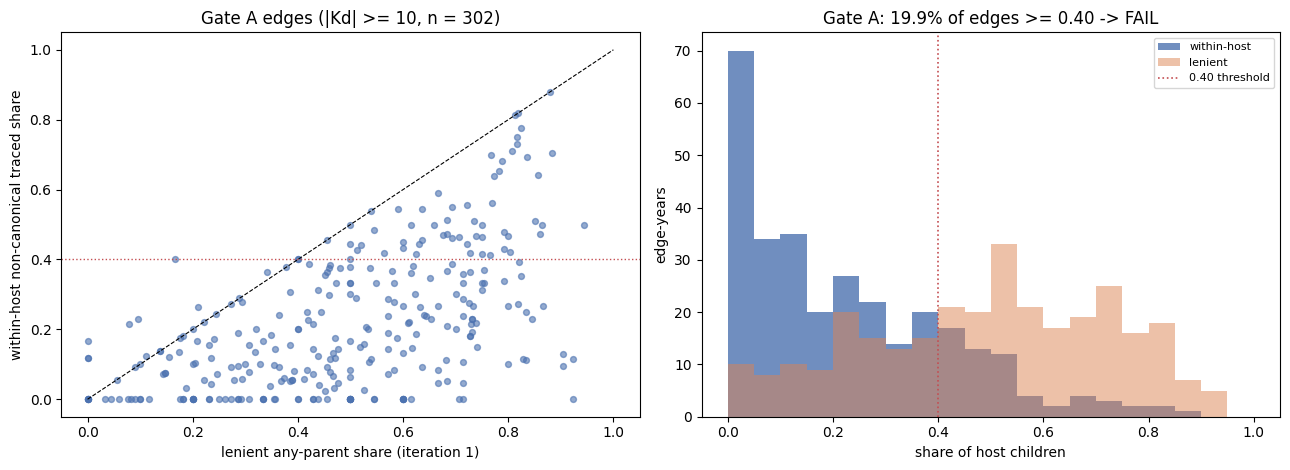

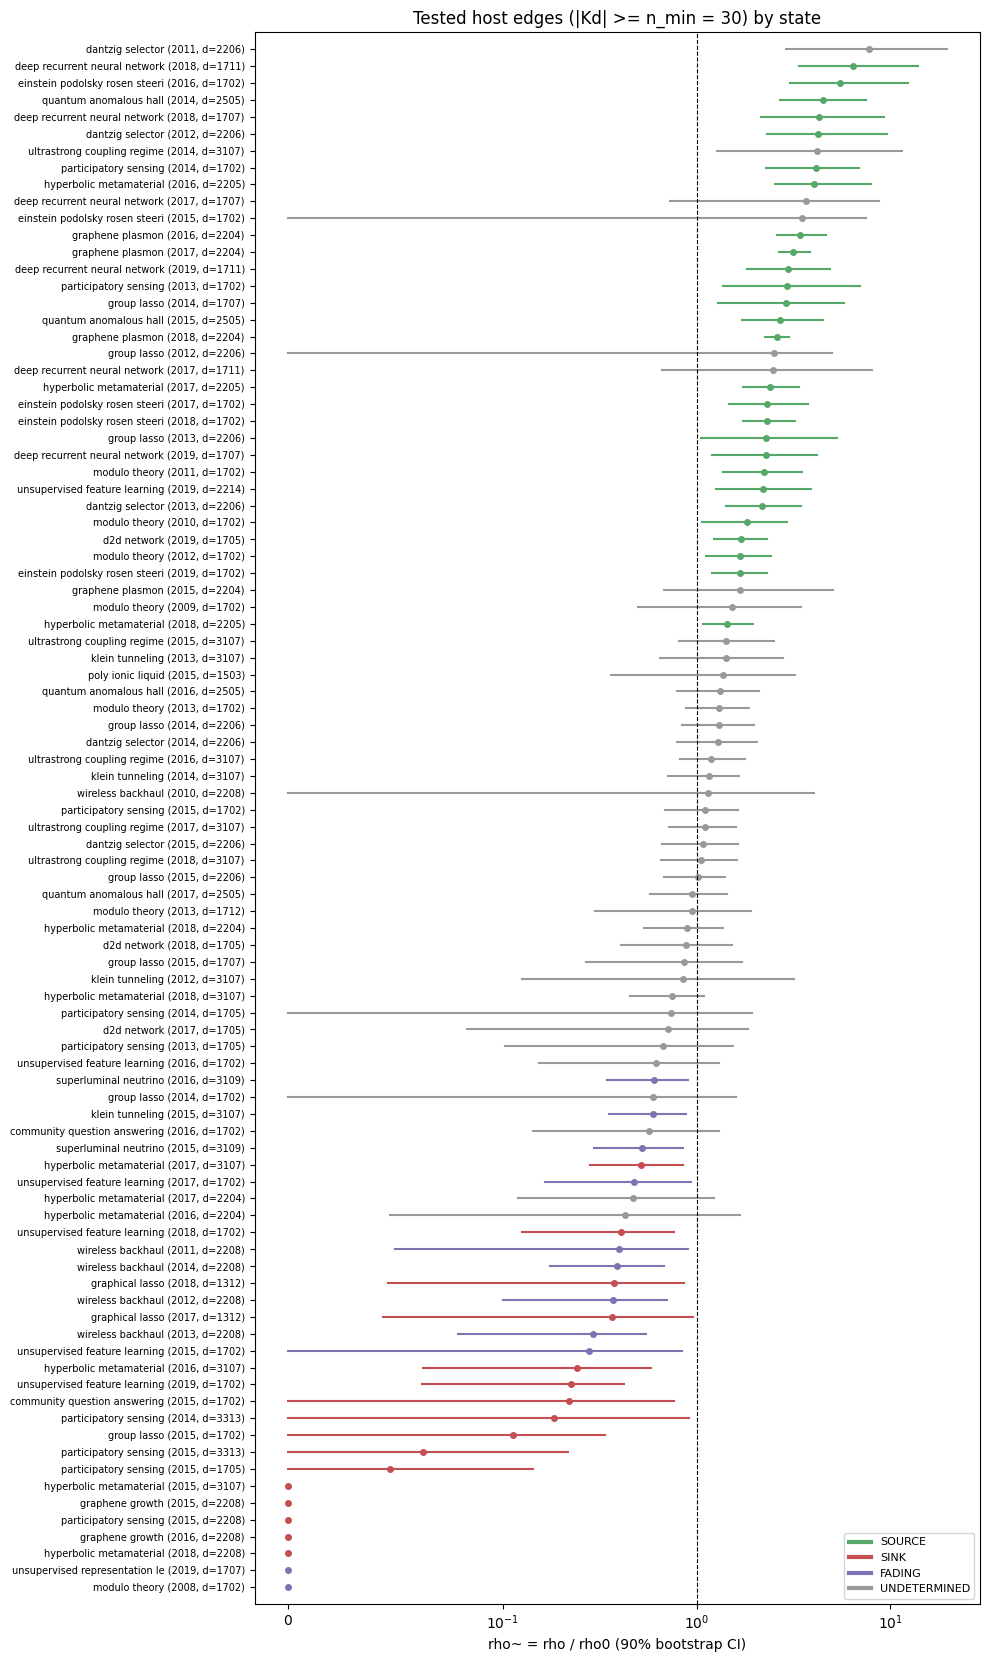

In [16]:
pd.set_option("display.width", 200)
print("n_min rule:", "rule_not_met" if viab_summary["n_min"]["rule_not_met_flag"] else "met",
      "-> n_min =", viab_summary["n_min"]["n_min_main"])
print(pd.DataFrame(viab_summary["n_min"]["bins"]).to_string(index=False))

# --- tested edges ---
cols = ["phrase", "t", "d", "n_children", "n_parents", "rho", "rho0", "rho0_level", "rho_tilde", "rho_tilde_lo",
        "rho_tilde_hi", "m", "m_lo", "q_greater", "q_less", "state_main", "growing_edge"]
tested = viab[viab.tested_main].sort_values(["state_main", "rho_tilde"], ascending=[True, False])
print(f"\nTested edges (n_min = {viab_summary['n_min']['n_min_main']}): {len(tested)}")
print(tested[cols].round(3).to_string(index=False))
print("\nState counts over all eligible host edges:", viab.state_main.value_counts().to_dict())
print("State counts by n_min:", {k: {s: int(v) for s, v in viab[f"state_nmin{k}"].value_counts().items()} for k in NMIN_BINS})

# --- consistency with the full run (same code, full 206-concept corpus) ---
full = pd.DataFrame([dict(r, concept_id=e["concept"]["concept_id"]) for e in data["examples"]
                     for r in e["full_run_host_edges"] if e["concept"]["concept_id"] in set(viab.concept_id)])
mg = viab.merge(full, on=["concept_id", "t", "d"], suffixes=("", "_full"))
for c in ["rho", "m", "within_host_share", "lenient_share"]:
    diff = np.nanmax(np.abs(mg[c].to_numpy(float) - mg[f"{c}_full"].to_numpy(float))) if len(mg) else np.nan
    print(f"max |{c} - full-run {c}| over {len(mg)} matched edges: {diff:.2e}")
if len(mg):
    print("state agreement with full run (differs only via rho0 from fewer references / smaller B):",
          round(float((mg.state_main == mg.state_main_full).mean()), 3))

# --- plots ---
ga = pd.read_parquet(OUT_GATE_A / "gate_a_host_edges.parquet")
ga = ga[ga.n_children >= 10]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(ga.lenient_share, ga.within_host_share, s=18, alpha=.6, color="#4C72B0")
ax[0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0].axhline(0.40, color="#C44E52", lw=1, ls=":")
ax[0].set_xlabel("lenient any-parent share (iteration 1)")
ax[0].set_ylabel("within-host non-canonical traced share")
ax[0].set_title(f"Gate A edges (|Kd| >= 10, n = {len(ga)})")
ax[1].hist(ga.within_host_share, bins=20, range=(0, 1), color="#4C72B0", alpha=.8, label="within-host")
ax[1].hist(ga.lenient_share, bins=20, range=(0, 1), color="#DD8452", alpha=.5, label="lenient")
ax[1].axvline(0.40, color="#C44E52", lw=1.2, ls=":", label="0.40 threshold")
ax[1].set_xlabel("share of host children")
ax[1].set_ylabel("edge-years")
ax[1].set_title(f"Gate A: {gate_a_verdict['share_edges_ge_040']:.1%} of edges >= 0.40 -> {gate_a_verdict['verdict'].split()[0]}")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

colors = {"SOURCE": "#55A868", "SINK": "#C44E52", "FADING": "#8172B3", "UNDETERMINED": "#999999"}
tp = tested.sort_values("rho_tilde").reset_index(drop=True)
fig, ax2 = plt.subplots(figsize=(10, 2 + 0.16 * len(tp)))
for i, r in tp.iterrows():
    ax2.plot([r.rho_tilde_lo, r.rho_tilde_hi], [i, i], color=colors[r.state_main], lw=1.5)
    ax2.plot(r.rho_tilde, i, "o", color=colors[r.state_main], ms=4)
ax2.axvline(1, color="k", lw=.8, ls="--")
ax2.set_xscale("symlog", linthresh=0.1)
ax2.set_yticks(range(len(tp)))
ax2.set_yticklabels([f"{p[:30]} ({t}, d={d})" for p, t, d in zip(tp.phrase, tp.t, tp.d)], fontsize=7)
ax2.set_ylim(-1, len(tp))
ax2.set_xlabel("rho~ = rho / rho0 (90% bootstrap CI)")
ax2.set_title(f"Tested host edges (|Kd| >= n_min = {viab_summary['n_min']['n_min_main']}) by state")
for s_, c in colors.items():
    ax2.plot([], [], color=c, lw=3, label=s_)
ax2.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Full-run headline numbers (for reference)

On the full corpus (184 main + 22 reference concepts, B = 1000, 4 CPUs, about 25 min for all stages), the same code gives:

| Step | Full-run result |
|---|---|
| Lenient loader check | reproduced exactly: 0.5518 (n = 41,861); 2010–14: 0.3174/0.3613/0.3476/0.4130/0.5171; reference 0.5311 |
| **Gate A** | **FAIL**: 17.3% of 724 host edge-years (97 concepts) have a within-host share ≥ 0.40 (mean 0.20, median 0.15). The lenient share on the same edges is 0.48, the within-origin share 0.47 and the reference-arm host share 0.13. |
| Viability layer | 779 eligible edges (100 concepts). The n_min rule was not met (log-ρ CI widths 1.3–1.8), so n_min = 30. 169 tested edges in 38 concepts: SOURCE 63, SINK 26, FADING 7, UNDETERMINED 683. The sensitivities agree on 94–99% of edges. |
| Synthetic validation | FDR 0.209 against the pre-declared 0.15 limit, so it **fails**. SOURCE is reliable (FDR 0.13); SINK (0.40) and FADING (0.28) are not. |
| Power (H1 / Gate B) | H1 is **pilot only** (N_c = 38, MDE ΔAUC 0.134 at a base AUC of 0.70). Gate B **FAILS** with 0 labelled episodes. |
| Baseline | Spearman(ρ̃, W1 momentum) = 0.14 |

Because Gate A failed, every viability label above is **descriptive only**.